In [16]:
import numpy as np


def gbf(x, exp, pot, pos=0):
    x = x - pos
    return x ** pot * np.exp(-exp * x ** 2)

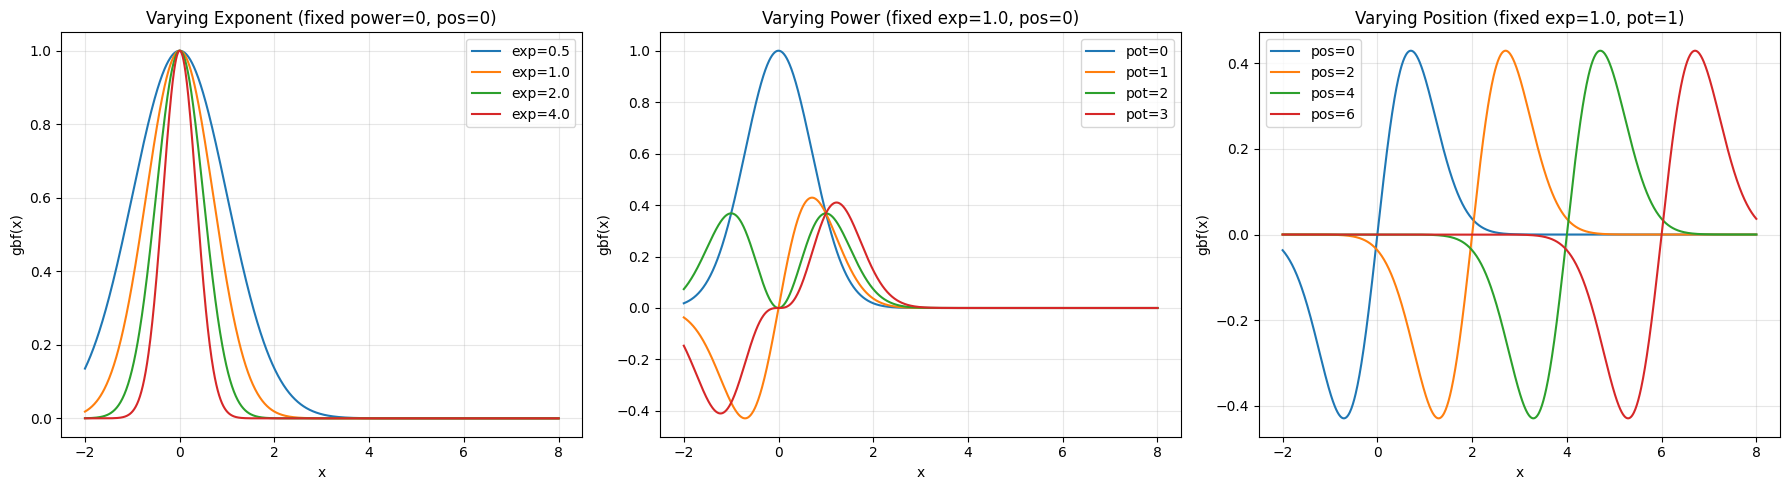

In [17]:
import matplotlib.pyplot as plt

# Create x values
x = np.linspace(-2, 8, 1000)

# Plot several GBF functions with different exponents and powers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left plot: varying exponent (alpha) with fixed power
axes[0].set_title('Varying Exponent (fixed power=0, pos=0)')
for exp in [0.5, 1.0, 2.0, 4.0]:
    y = gbf(x, exp, pot=0, pos=0)
    axes[0].plot(x, y, label=f'exp={exp}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('gbf(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Middle plot: varying power with fixed exponent
axes[1].set_title('Varying Power (fixed exp=1.0, pos=0)')
for pot in [0, 1, 2, 3]:
    y = gbf(x, exp=1.0, pot=pot, pos=0)
    axes[1].plot(x, y, label=f'pot={pot}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('gbf(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Right plot: varying position with fixed exponent and power
axes[2].set_title('Varying Position (fixed exp=1.0, pot=1)')
for pos in [0, 2, 4, 6]:
    y = gbf(x, exp=1.0, pot=1, pos=pos)
    axes[2].plot(x, y, label=f'pos={pos}')
axes[2].set_xlabel('x')
axes[2].set_ylabel('gbf(x)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

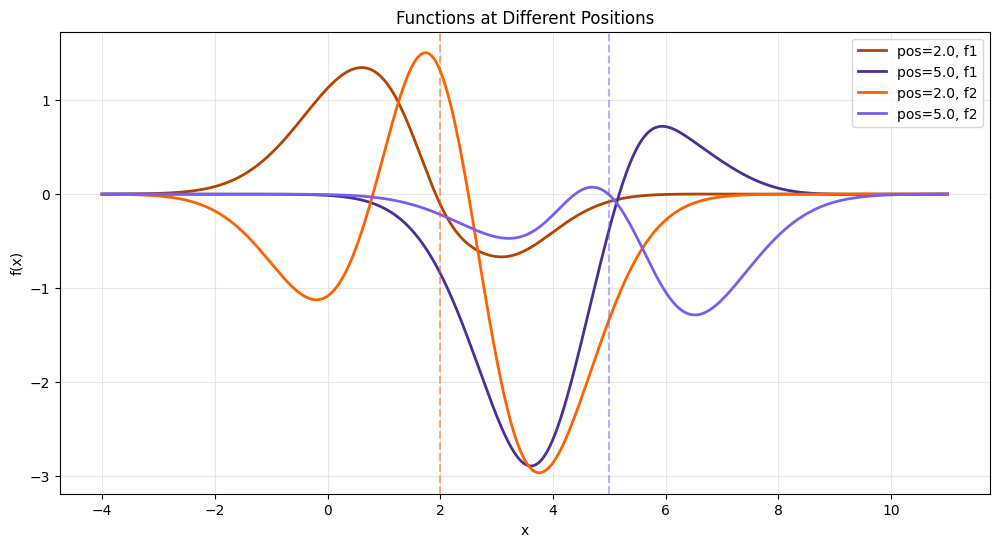

In [18]:
positions = [2.0, 5.0]

basis_exps = [0.3, 1.0, 2.0, 4.0, 0.3, 1.0, 0.3, 1.0]
basis_pots = [0, 0, 0,  0, 1, 1,  2, 2]

# Create x values
x = np.linspace(-4, 11, 1000)

# Generate random coefficients for 3 functions at each position
np.random.seed(45)
num_functions = 3
coeffs = np.random.randn(len(positions), num_functions, len(basis_exps))
coeffs[:, :, [3, 5, 7]] = 0.0
coeffs = coeffs[:, :2]
num_functions = 2


# Compute functions at each position
functions = np.zeros((len(positions), num_functions, len(x)))

for pos_idx, pos in enumerate(positions):
    for func_idx in range(num_functions):
        for basis_idx, (exp, pot) in enumerate(zip(basis_exps, basis_pots)):
            functions[pos_idx, func_idx] += coeffs[pos_idx, func_idx, basis_idx] * gbf(x, exp, pot, pos=pos)

# Define color palettes
red_colors = ['#B34400', '#fe6100', '#FFB380']  # dark to light orange
blue_colors = ['#4B2F98', '#785ef0', '#B3A1F7']  # dark to light purple

# Plot all functions on a single plot
plt.figure(figsize=(12, 6))

for func_idx in range(num_functions):
    plt.plot(x, functions[0, func_idx], color=red_colors[func_idx], 
             label=f'pos={positions[0]}, f{func_idx+1}', linewidth=2)
    plt.plot(x, functions[1, func_idx], color=blue_colors[func_idx], 
             label=f'pos={positions[1]}, f{func_idx+1}', linewidth=2)

plt.axvline(positions[0], color='#fe6100', linestyle='--', alpha=0.5)
plt.axvline(positions[1], color='#785ef0', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Functions at Different Positions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

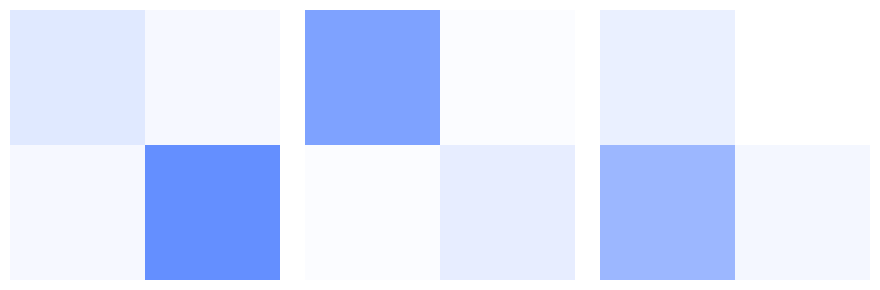

Overlap matrix within pos1 (red functions):
[[ 3.55602399  1.31593239]
 [ 1.31593239 16.72886511]]

Overlap matrix within pos2 (blue functions):
[[13.91324788  0.68770672]
 [ 0.68770672  2.85815879]]

Overlap matrix between pos1 and pos2:
[[ 2.5541638   0.35831633]
 [10.73235578  1.46601414]]


In [19]:
# Calculate overlap matrices using numerical integration
dx = x[1] - x[0]

# Overlap matrix within pos1 (red functions)
overlap_pos1 = np.zeros((num_functions, num_functions))
for i in range(num_functions):
    for j in range(num_functions):
        overlap_pos1[i, j] = np.sum(functions[0, i] * functions[0, j]) * dx

# Overlap matrix within pos2 (blue functions)
overlap_pos2 = np.zeros((num_functions, num_functions))
for i in range(num_functions):
    for j in range(num_functions):
        overlap_pos2[i, j] = np.sum(functions[1, i] * functions[1, j]) * dx

# Overlap matrix between pos1 and pos2
overlap_cross = np.zeros((num_functions, num_functions))
for i in range(num_functions):
    for j in range(num_functions):
        overlap_cross[i, j] = np.sum(functions[0, i] * functions[1, j]) * dx

# Determine common scale for all matrices
vmin = min(overlap_pos1.min(), overlap_pos2.min(), overlap_cross.min())
vmax = max(overlap_pos1.max(), overlap_pos2.max(), overlap_cross.max())

# Visualize the three overlap matrices
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Pos1 overlap
from matplotlib.colors import LinearSegmentedColormap
orange_cmap = LinearSegmentedColormap.from_list('orange', ['#FFFFFF', '#648fff'])
purple_cmap = LinearSegmentedColormap.from_list('purple', ['#FFFFFF', '#dc267f'])
diverging_cmap = LinearSegmentedColormap.from_list('orange_purp',  ['#FFFFFF', '#dc267f'])

im1 = axes[0].imshow(overlap_pos1, cmap=orange_cmap, aspect='equal', vmin=vmin, vmax=vmax)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# Pos2 overlap
im2 = axes[1].imshow(overlap_pos2, cmap=orange_cmap, aspect='equal', vmin=vmin, vmax=vmax)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

# Cross overlap
im3 = axes[2].imshow(overlap_cross, cmap=orange_cmap, aspect='equal', vmin=vmin, vmax=vmax)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].spines['bottom'].set_visible(False)
axes[2].spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig("../data/figures/overlap_matrices.pdf")
plt.show()

print("Overlap matrix within pos1 (red functions):")
print(overlap_pos1)
print("\nOverlap matrix within pos2 (blue functions):")
print(overlap_pos2)
print("\nOverlap matrix between pos1 and pos2:")
print(overlap_cross)

Basis overlap matrix S11 (pos1 with itself):
[[ 2.288  1.555  1.169  0.855  0.    -0.     1.907  0.598]
 [ 1.555  1.253  1.023  0.793 -0.    -0.     0.598  0.313]
 [ 1.169  1.023  0.886  0.724 -0.    -0.     0.254  0.171]
 [ 0.855  0.793  0.724  0.627 -0.    -0.     0.099  0.079]
 [ 0.    -0.    -0.    -0.     1.907  0.598  0.    -0.   ]
 [-0.    -0.    -0.    -0.     0.598  0.313 -0.    -0.   ]
 [ 1.907  0.598  0.254  0.099  0.    -0.     4.767  0.69 ]
 [ 0.598  0.313  0.171  0.079 -0.    -0.     0.69   0.235]]

Basis overlap matrix S22 (pos2 with itself):
[[ 2.288  1.555  1.169  0.855 -0.     0.     1.907  0.598]
 [ 1.555  1.253  1.023  0.793  0.     0.     0.598  0.313]
 [ 1.169  1.023  0.886  0.724  0.     0.     0.254  0.171]
 [ 0.855  0.793  0.724  0.627  0.    -0.     0.099  0.079]
 [-0.     0.     0.     0.     1.907  0.598 -0.     0.   ]
 [ 0.     0.     0.    -0.     0.598  0.313  0.     0.   ]
 [ 1.907  0.598  0.254  0.099 -0.     0.     4.767  0.69 ]
 [ 0.598  0.313  0.171 

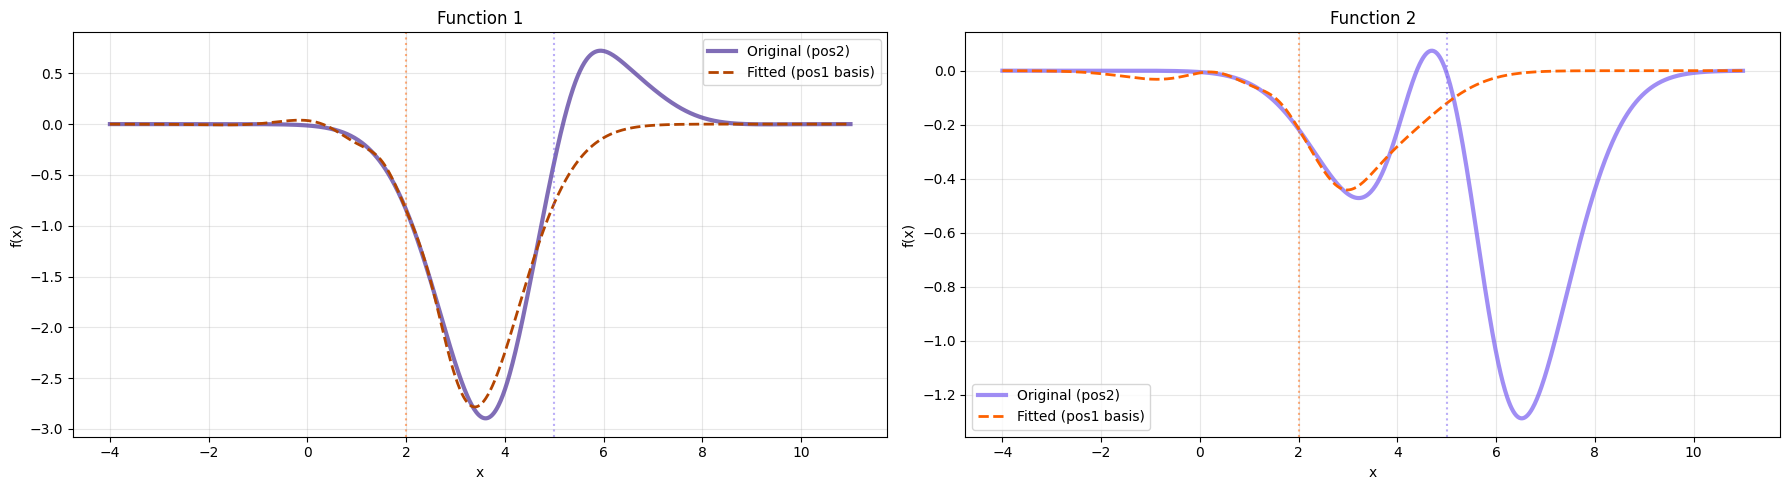


L2 error for function 1: 1.080814

L2 error for function 2: 1.584286


In [20]:
# Calculate overlap matrices for the basis functions (not the combined functions)
# Shape: (num_positions, num_basis, len(x))
basis_functions = np.zeros((len(positions), len(basis_exps), len(x)))

for pos_idx, pos in enumerate(positions):
    for basis_idx, (exp, pot) in enumerate(zip(basis_exps, basis_pots)):
        basis_functions[pos_idx, basis_idx] = gbf(x, exp, pot, pos=pos)

# Overlap matrix within basis functions at pos1
S11 = np.zeros((len(basis_exps), len(basis_exps)))
for i in range(len(basis_exps)):
    for j in range(len(basis_exps)):
        S11[i, j] = np.sum(basis_functions[0, i] * basis_functions[0, j]) * dx

# Overlap matrix within basis functions at pos2
S22 = np.zeros((len(basis_exps), len(basis_exps)))
for i in range(len(basis_exps)):
    for j in range(len(basis_exps)):
        S22[i, j] = np.sum(basis_functions[1, i] * basis_functions[1, j]) * dx

# Overlap matrix between basis functions at pos1 and pos2
S12 = np.zeros((len(basis_exps), len(basis_exps)))
for i in range(len(basis_exps)):
    for j in range(len(basis_exps)):
        S12[i, j] = np.sum(basis_functions[0, i] * basis_functions[1, j]) * dx

print("Basis overlap matrix S11 (pos1 with itself):")
print(S11.round(3))
print("\nBasis overlap matrix S22 (pos2 with itself):")
print(S22.round(3))
print("\nBasis overlap matrix S12 (pos1 with pos2):")
print(S12.round(3))

# Calculate fitted coefficients using overlap matrices
# fitted_coeffs = S11^(-1) @ S12 @ coeffs[1]
# This transforms coefficients from pos2 basis to pos1 basis

S11_inv = np.linalg.inv(S11 + 1e-2 * np.eye(len(basis_exps)))  # Regularization for stability
fitted_coeffs = (S11_inv @ S12 @ coeffs[1].T).T

# Reconstruct fitted functions using pos1 basis
fitted_functions = np.zeros((num_functions, len(x)))
for func_idx in range(num_functions):
    for basis_idx in range(len(basis_exps)):
        fitted_functions[func_idx] += fitted_coeffs[func_idx, basis_idx] * basis_functions[0, basis_idx]

print("\nFitted coefficients (pos2 functions in pos1 basis):")
print(fitted_coeffs.round(3))
print("\nOriginal pos2 coefficients:")
print(coeffs[1].round(3))

# Visualize original and fitted functions
fig, axes = plt.subplots(1, num_functions, figsize=(18, 5))

for func_idx in range(num_functions):
    ax = axes[func_idx]
    
    # Original pos2 function (blue)
    ax.plot(x, functions[1, func_idx], color=blue_colors[func_idx], 
            linewidth=3, label=f'Original (pos2)', alpha=0.7)
    
    # Fitted function in pos1 basis (dashed red)
    ax.plot(x, fitted_functions[func_idx], color=red_colors[func_idx], 
            linewidth=2, linestyle='--', label=f'Fitted (pos1 basis)')
    
    # Mark positions
    ax.axvline(positions[0], color='#fe6100', linestyle=':', alpha=0.5)
    ax.axvline(positions[1], color='#785ef0', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Function {func_idx+1}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and print fitting errors
for func_idx in range(num_functions):
    error = np.sqrt(np.sum((functions[1, func_idx] - fitted_functions[func_idx])**2) * dx)
    print(f"\nL2 error for function {func_idx+1}: {error:.6f}")

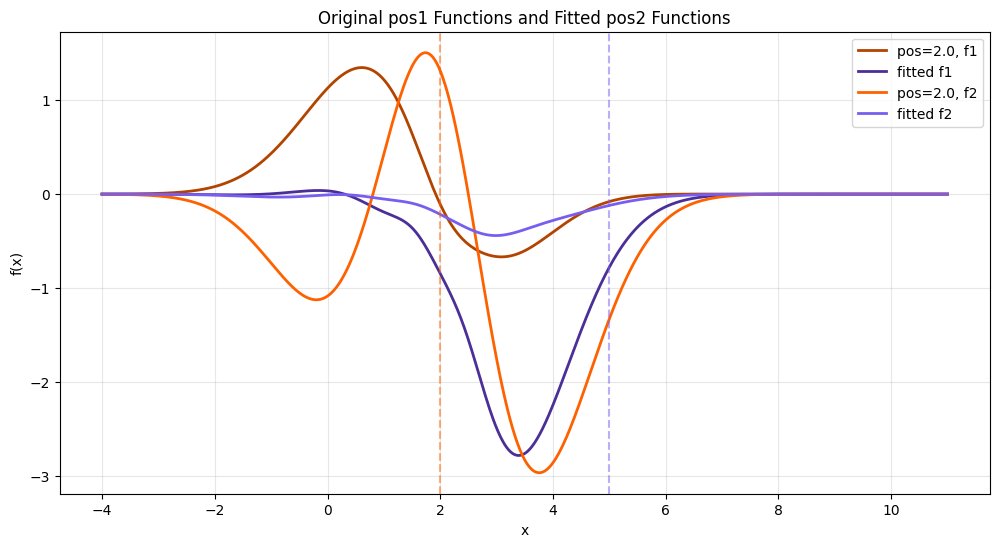

In [21]:
# Define color palettes
red_colors = ['#B34400', '#fe6100', '#FFB380']  # dark to light orange
blue_colors = ['#4B2F98', '#785ef0', '#B3A1F7']  # dark to light purple

# Plot all functions on a single plot
plt.figure(figsize=(12, 6))

for func_idx in range(num_functions):
    plt.plot(x, functions[0, func_idx], color=red_colors[func_idx], 
             label=f'pos={positions[0]}, f{func_idx+1}', linewidth=2)
    plt.plot(x, fitted_functions[func_idx], color=blue_colors[func_idx], 
             label=f'fitted f{func_idx+1}', linewidth=2)

plt.axvline(positions[0], color='#fe6100', linestyle='--', alpha=0.5)
plt.axvline(positions[1], color='#785ef0', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Original pos1 Functions and Fitted pos2 Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Matrix W1 (for pos1 self-interaction):
[[-0.25   0.439]
 [ 0.415 -0.535]]

Matrix W2 (for pos2->pos1 message passing):
[[-0.489 -0.572]
 [ 0.62   0.029]]
(2, 2, 8) (2, 8)

New pos1 coefficients:
[[ 1.036e+00 -8.000e-02 -5.600e-02  2.410e-01  7.480e-01 -3.340e-01
  -5.530e-01  3.040e-01]
 [-1.524e+00  4.280e-01  9.200e-02 -2.740e-01 -9.490e-01  4.810e-01
   8.030e-01  1.000e-03]]


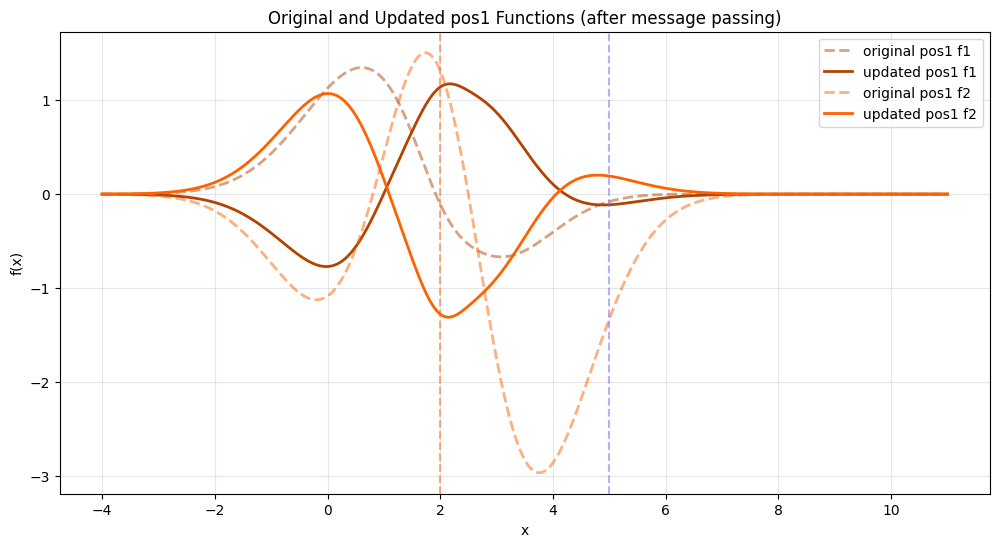

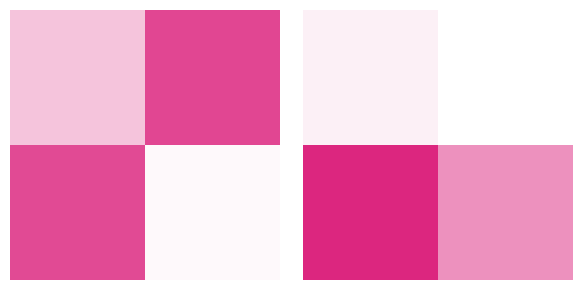

In [22]:
# Sample two random 3x3 matrices for message passing
np.random.seed(44)
W1 = np.random.randn(num_functions, num_functions) / 3
W2 = np.random.randn(num_functions, num_functions) / 3

print("Matrix W1 (for pos1 self-interaction):")
print(W1.round(3))
print("\nMatrix W2 (for pos2->pos1 message passing):")
print(W2.round(3))
print(coeffs.shape, fitted_coeffs.shape)

# Calculate new coefficients for pos1
# new_coeffs_pos1 = W1 @ coeffs[0] + W2 @ fitted_coeffs
new_coeffs_pos1 = (W1 @ coeffs[0]) + (W2 @ fitted_coeffs)

print("\nNew pos1 coefficients:")
print(new_coeffs_pos1.round(3))

# Reconstruct new pos1 functions using updated coefficients
new_functions_pos1 = np.zeros((num_functions, len(x)))
for func_idx in range(num_functions):
    for basis_idx in range(len(basis_exps)):
        new_functions_pos1[func_idx] += new_coeffs_pos1[func_idx, basis_idx] * basis_functions[0, basis_idx]

# Visualize original and updated pos1 functions
plt.figure(figsize=(12, 6))

for func_idx in range(num_functions):
    plt.plot(x, functions[0, func_idx], color=red_colors[func_idx], 
             linewidth=2, linestyle='--', alpha=0.5, label=f'original pos1 f{func_idx+1}')
    plt.plot(x, new_functions_pos1[func_idx], color=red_colors[func_idx], 
             linewidth=2, label=f'updated pos1 f{func_idx+1}')

plt.axvline(positions[0], color='#fe6100', linestyle='--', alpha=0.5)
plt.axvline(positions[1], color='#785ef0', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Original and Updated pos1 Functions (after message passing)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# show the matrices W1 and W2
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

orange_cmap = LinearSegmentedColormap.from_list('orange', ['#FFFFFF', '#648fff'])
purple_cmap = LinearSegmentedColormap.from_list('purple', ['#FFFFFF', '#dc267f'])
diverging_cmap = LinearSegmentedColormap.from_list('orange_purp',  ['#FFFFFF', '#dc267f'])


vmin = min(W1.min(), W2.min())
vmax = max(W1.max(), W2.max())

im1 = axes[0].imshow(W1, cmap=purple_cmap, aspect='equal', vmin=vmin, vmax=vmax)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

im2 = axes[1].imshow(W2, cmap=purple_cmap, aspect='equal', vmin=vmin, vmax=vmax)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig("../data/figures/message_passing_matrices.pdf")
plt.show()

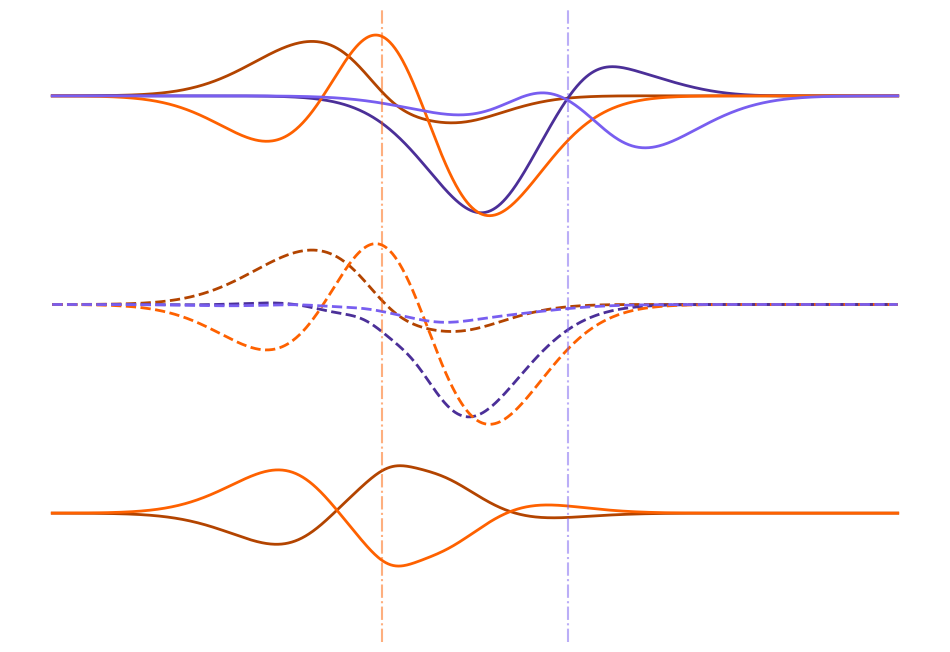

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True)

# Top plot: Original functions at both positions
for func_idx in range(num_functions):
    axes[0].plot(x, functions[0, func_idx], color=red_colors[func_idx], linewidth=2)
    axes[0].plot(x, functions[1, func_idx], color=blue_colors[func_idx], linewidth=2)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

# Middle plot: Original pos1 and fitted pos2
for func_idx in range(num_functions):
    axes[1].plot(x, functions[0, func_idx], color=red_colors[func_idx], linewidth=2, linestyle='--')
    axes[1].plot(x, fitted_functions[func_idx], color=blue_colors[func_idx], linewidth=2, linestyle='--')
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

# Bottom plot: Original and updated pos1
for func_idx in range(num_functions):
    # axes[2].plot(x, functions[0, func_idx], color=red_colors[func_idx], 
    #              linewidth=2, linestyle='--', alpha=0.5)
    axes[2].plot(x, new_functions_pos1[func_idx], color=red_colors[func_idx], linewidth=2)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].spines['bottom'].set_visible(False)
axes[2].spines['left'].set_visible(False)

# Add vertical lines across all subplots using figure coordinates
for pos, color in zip(positions, ['#fe6100', '#785ef0']):
    fig.add_artist(plt.Line2D([0.125 + (pos - x.min()) / (x.max() - x.min()) * 0.775, 
                                0.125 + (pos - x.min()) / (x.max() - x.min()) * 0.775], 
                               [0.11, 0.9], 
                               transform=fig.transFigure, 
                               color=color, linestyle='-.', alpha=0.5))

plt.subplots_adjust(hspace=0.05)
plt.savefig('../data/figures/message_passing_1d.pdf', dpi=300)
plt.show()